## cbig_network_correspondence Toolbox


A network correspondence toolbox for quantitative evaluation of novel neuroimaging results
https://github.com/rubykong/cbig_network_correspondence?tab=readme-ov-file

On local:
* in preexisitng neuro env: problems to deinstall VTK
* in new conda env: pip install cbig_network_correspondence -> compilation error

WORKED on sciencecloud:
* new env. - installation works, but env not usable in VSC [neocortexmaps (Python -1.-1.-1)] prob. due to this python problem (sinde FSL installation on mounted volume... now added expor PARH=.../miniforge3/python.... but error wiht this new env still persiist ?!
)
* in `numrefields_c`, - installation works (install matplotlib = 3.7 !), but no space left on device to save necessary data: 
~/miniconda3/envs/numrefields_c/lib/python3.10/site-packages/cbig_network_correspondence/data (has ~ 1.5 G !)

--> put in `/home/ubuntu/miniconda3/envs/numrefields_c/lib/python3.10/site-packages/cbig_network_correspondence/__init__.py` 
data_dir = os.environ.get("CBIG_NETWORK_CORRESPONDENCE_DATA", os.path.join(os.path.dirname(__file__), 'data'))
& #out the check-git lines (repo_dir = Repo(data_dir)) as it is not a valid git-repo

opened : `~/miniconda3/envs/numrefields_c/lib/python3.10/site-packages/cbig_network_correspondence` and put 
`PROJECT_PATH = '/mnt_04/cbig_network_correspondence_data'` there, too ()



In [ ]:
import os
data_dir = os.getenv('CBIG_NETWORK_CORRESPONDENCE_DATA') # or hardcode it!
print(f"Current data directory is: {data_dir}")
# --> suzzesfullly set


Current data directory is: /mnt_04/cbig_network_correspondence_data


In [ ]:
# provided example

atlas_names_list = ["EG17","MG360J12"]
example = cnc.load_example
# the example config file
print(example.example_config)
# the path to the example data
print(example.example_nii)
ref_params = cnc.compute_overlap_with_atlases.DataParams(example.example_config, example.example_nii)
cnc.compute_overlap_with_atlases.network_correspondence(ref_params, atlas_names_list,"~/NCTexample/example_results")


# Own brain Map:

* BRAIN data:
Here are the formats we support:
.npy file: The file should contain a numpy array with shape (64984, 1) for fs_LR_32k space or (81924, 1) for fsaverage6 space.

* CONFIG file:
nano /mnt_03/ds-dnumrisk/derivatives/encoding_model.denoise/averages/group-all_r2_space-fsLR_den-32k_hemi-both_config -->

[data_info]
Data_Name: average_nPRF_r2
Data_Space: fs_LR_32k
Data_Type: Metric
Data_Threshold: [0.023,Inf]

In [ ]:
# create necessary npy file from GIFTI
import nibabel as nib
import numpy as np
import os.path as op

bids_folder = '/mnt_03/ds-dnumrisk'
hemi = 'L'

pati_nPRF = op.join(bids_folder, 'derivatives/encoding_model.denoise/averages')

# Load the GIFTI file
im_L = nib.load(op.join(pati_nPRF, 'group-all_desc-r2.optim.nilearn_space-fsLR_den-32k_hemi-L.func.gii'))
im_R = nib.load(op.join(pati_nPRF, 'group-all_desc-r2.optim.nilearn_space-fsLR_den-32k_hemi-R.func.gii'))

map_nPRF = np.concatenate((im_L.darrays[0].data, im_R.darrays[0].data), axis=0)
map_nPRF = np.reshape(map_nPRF,(map_nPRF.shape[0],1))
print(map_nPRF.shape)

np.save(op.join(pati_nPRF, 'group-all_desc-r2.optim.nilearn_space-fsLR_den-32k_hemi-both.npy'), map_nPRF)

# look where to set the threshold
#import matplotlib.pyplot as plt
#plt.hist(map_nPRF, bins=100)

(64984, 1)


Computing overlap with MG360J12
This is a soft parcellation or metric data.
This is a hard parcellation.
Computing overlap with TY17
This is a soft parcellation or metric data.
This is a hard parcellation.
Performing permutation with MG360J12
This is a soft parcellation or metric data.
This is a hard parcellation.
This is a soft parcellation or metric data.
This is a hard parcellation.
Performing permutation with TY17
This is a soft parcellation or metric data.
This is a hard parcellation.
This is a soft parcellation or metric data.
This is a hard parcellation.
Single dimension data is provided. Visualize network correspondence as circular chart.


/home/ubuntu/miniconda3/envs/numrefields_c/lib/python3.10/site-packages/cbig_network_correspondence/visualize_report_lib.py:472: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_all[dice_c] = df_all[dice_c].replace(0,0.0001)
/home/ubuntu/miniconda3/envs/numrefields_c/lib/python3.10/site-packages/cbig_network_correspondence/visualize_report_lib.py:475: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_all[p_value_c] = df_all[p_value_c].fillna(0)


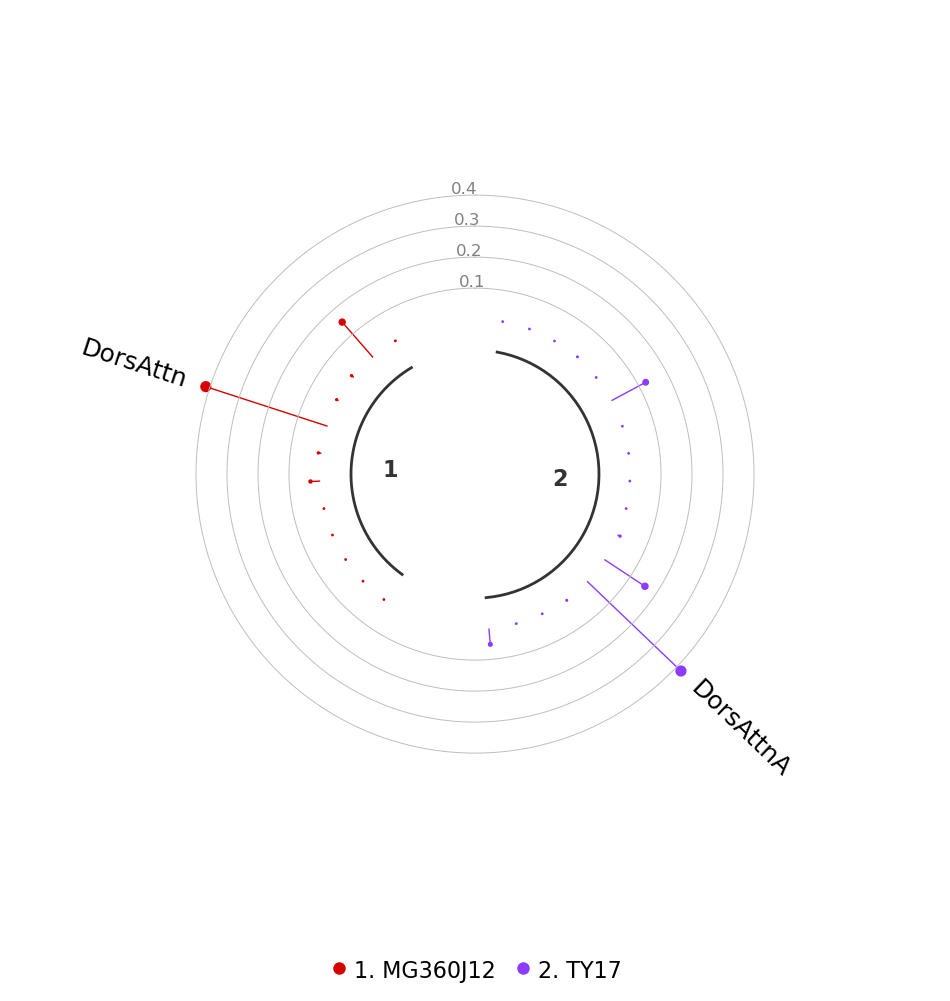

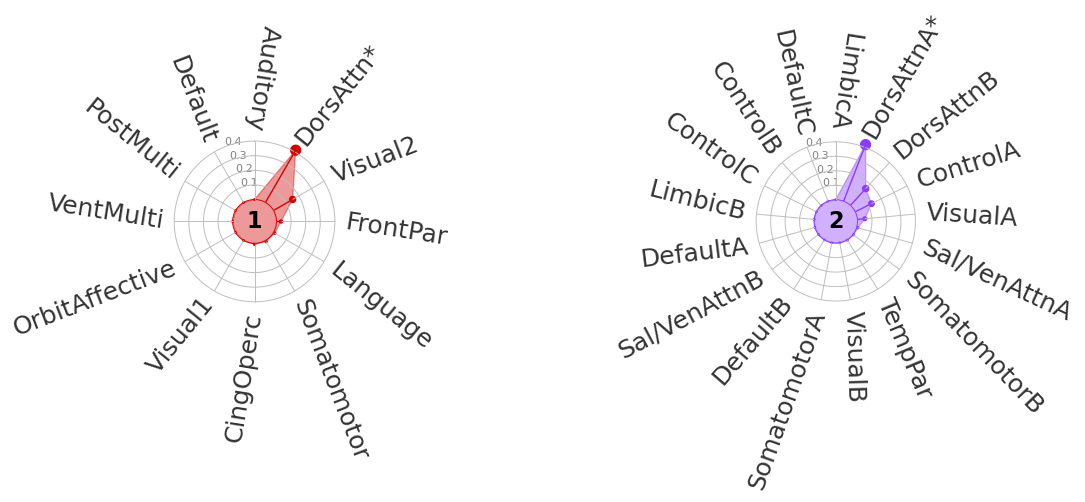

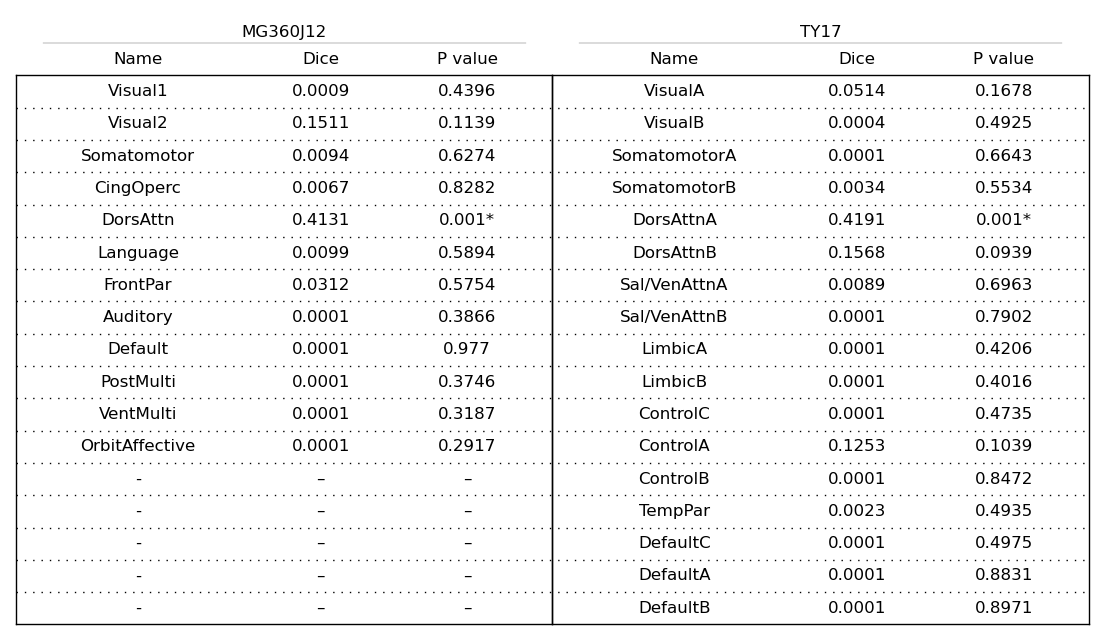

In [22]:
# my own data:
bids_folder = '/mnt_03/ds-dnumrisk'
pati_nPRF = op.join(bids_folder, 'derivatives/encoding_model.denoise/averages')

atlas_names_list = ['MG360J12','TY17']

config_nPRF = op.join(pati_nPRF,'group-all_r2_space-fsLR_den-32k_hemi-both_config')
map_nPRF = op.join(pati_nPRF, 'group-all_desc-r2.optim.nilearn_space-fsLR_den-32k_hemi-both.npy')
ref_params = cnc.compute_overlap_with_atlases.DataParams(config_nPRF,map_nPRF )
cnc.compute_overlap_with_atlases.network_correspondence(ref_params, atlas_names_list,"~/NCTexample/example_results")
